In [1]:
## import modules
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.mask import mask
from PIL import Image
from rasterstats import zonal_stats
from rasterio.plot import show
from rasterio import warp
from sklearn.preprocessing import StandardScaler
from shapely.validation import make_valid
import deweydatapy as ddp
import glob
from tqdm import tqdm
from datetime import datetime
import csv
import shapely.geometry as geom
from matplotlib.colors import ListedColormap
from pathlib import Path
from shapely.validation import make_valid


## set working directory
import os
os.chdir("/Users/yuxin/Dropbox/DDDI/Illegal-Dumping")

In [2]:
## import acs cbg polygon as geobase
pa_2023 = gpd.read_file('data/tiger/tl_2023_42_bg/tl_2023_42_bg.shp')
philly_2023 = pa_2023[pa_2023['COUNTYFP']=='101']
philly_2023 = philly_2023.to_crs(epsg = 26918)

In [3]:
## skip dowloading: finished in cov.ipynb

## get all CSV.GZ files in the folder
files = glob.glob('data/foot_traffic/*.csv.gz')

## read all CSV.GZ files
df_list = []
for file in tqdm(files, desc="Processing files", unit="file"):
    df = pd.read_csv(file)
    df = df.loc[df['AREA'].astype(str).str[:5] == '42101']  # keep only Philly CBGs
    df_list.append(df)

## concatenate all dataframes
df = pd.concat(df_list)

Processing files: 100%|██████████| 48/48 [01:43<00:00,  2.15s/file]


In [4]:
## Foot Traffic Data is using 2018 CBG information
## download cbg shapfile here: https://www2.census.gov/geo/tiger/TIGER2022/BG/

## load cbg shapefile from 2018 to 2024
# Path to the tiger folder
tiger_path = Path("data/tiger")

# Dictionary to store the loaded shapefiles
pa_data = {}

# Loop through each year folder in the tiger directory
for folder in tiger_path.iterdir():
    if folder.is_dir() and folder.name.startswith("tl_"):
        # Extract year from folder name (e.g., "tl_2023_42_bg" -> "2023")
        year = folder.name.split("_")[1]
        
        # Find the shapefile in the folder
        shp_file = None
        for file in folder.iterdir():
            if file.suffix == ".shp":
                shp_file = file
                break
        
        if shp_file:
            try:
                # Load the shapefile
                temp_gdf = gpd.read_file(shp_file)
                
                # Filter to keep only records where COUNTYFP is '101'
                temp_gdf = temp_gdf[temp_gdf['COUNTYFP'] == '101']
                
                # Create variable named "pa_[year]"
                exec(f"pa_{year} = temp_gdf")
                print(f"Loaded {shp_file} as pa_{year} (filtered to COUNTYFP='101', {len(temp_gdf)} features)")
            except Exception as e:
                print(f"Error loading {shp_file}: {e}")
        else:
            print(f"No shapefile found in {folder}")

Loaded data/tiger/tl_2017_42_bg/tl_2017_42_bg.shp as pa_2017 (filtered to COUNTYFP='101', 1336 features)
Loaded data/tiger/tl_2021_42_bg/tl_2021_42_bg.shp as pa_2021 (filtered to COUNTYFP='101', 1338 features)
Loaded data/tiger/tl_2023_42_bg/tl_2023_42_bg.shp as pa_2023 (filtered to COUNTYFP='101', 1338 features)
Loaded data/tiger/tl_2018_42_bg/tl_2018_42_bg.shp as pa_2018 (filtered to COUNTYFP='101', 1336 features)
Loaded data/tiger/tl_2022_42_bg/tl_2022_42_bg.shp as pa_2022 (filtered to COUNTYFP='101', 1338 features)
Loaded data/tiger/tl_2020_42_bg/tl_2020_42_bg.shp as pa_2020 (filtered to COUNTYFP='101', 1338 features)
Loaded data/tiger/tl_2024_42_bg/tl_2024_42_bg.shp as pa_2024 (filtered to COUNTYFP='101', 1338 features)
Loaded data/tiger/tl_2019_42_bg/tl_2019_42_bg.shp as pa_2019 (filtered to COUNTYFP='101', 1336 features)


In [5]:
## keep only the columns needed
df_visit = df.copy()
df_visit = df_visit[['AREA', 'DATE_RANGE_START', 'DATE_RANGE_END', 'RAW_DEVICE_COUNTS','RAW_STOP_COUNTS','Y']]

# Ensure both are strings to match properly
df_visit['AREA'] = df_visit['AREA'].astype(str)
pa_2018['GEOID'] = pa_2018['GEOID'].astype(str)

# Filter
df_visit = df_visit[df_visit['AREA'].isin(pa_2018['GEOID'])]

## aggregate 4-year avg visiting count
df_avg = (
    df_visit
    .groupby("AREA", as_index=False)
    .agg({
        "RAW_DEVICE_COUNTS": "mean",
        "RAW_STOP_COUNTS": "mean"
    })
    .rename(columns={
        "RAW_DEVICE_COUNTS": "avg_d_cnt",
        "RAW_STOP_COUNTS": "avg_s_cnt",
        'AREA': "GEOID"
    })
)

df_avg['unique_device_ratio'] = round(df_avg['avg_d_cnt'] / df_avg['avg_s_cnt'], 2)
print(df_avg.shape)


(1336, 4)


In [6]:
## convert to gpd
# 1) Make sure keys are strings
pa_2018['GEOID'] = pa_2018['GEOID'].astype(str)
df_avg['GEOID'] = df_avg['GEOID'].astype(str)

# 2) LEFT join from the GeoDataFrame (keeps ALL polygons, geometry intact)
df_avg_geo = pa_2018.merge(df_avg, on='GEOID', how='left')

### Merge with 2023 CBG boundary

In [7]:
# --- inputs ---
A = df_avg_geo.copy()       # has avg_d_cnt, avg_s_cnt, unique_device_ratio
B = philly_2023.copy()      # has GEOID (finer CBGs)

# --- project to meters (Philly) + fix geometries ---
A = A.to_crs(26918); B = B.to_crs(26918)
A["geometry"] = A.geometry.apply(make_valid)
B["geometry"] = B.geometry.apply(make_valid)

# --- keep needed columns + areas ---
extensive_cols = ["avg_d_cnt", "avg_s_cnt"]
intensive_col  = "unique_device_ratio"

A = A[extensive_cols + [intensive_col, "geometry"]].copy()
B = B[["GEOID", "geometry"]].copy()

A["aid"]     = np.arange(len(A))
A["area_A"]  = A.area
B["area_B"]  = B.area
B_area = B[["GEOID", "area_B"]]

# --- intersections (handles splits, overlaps, reassignments) ---
AB = gpd.overlay(
    A[["aid","area_A"] + extensive_cols + [intensive_col, "geometry"]],
    B[["GEOID","geometry"]],
    how="intersection",
    keep_geom_type=False
)
AB = AB[AB.geometry.notna() & ~AB.geometry.is_empty].copy()
AB["area_int"] = AB.area
AB = AB[AB["area_int"] > 0].copy()

# share of A piece overlapped
AB["share_A"] = AB["area_int"] / AB["area_A"]

# --- EXTENSIVE: split totals from A into B by area share ---
for col in extensive_cols:
    AB[f"alloc_{col}"] = AB[col] * AB["share_A"]

ext_alloc = (AB.groupby("GEOID", as_index=False)[[f"alloc_{c}" for c in extensive_cols]].sum())

# --- INTENSIVE: area-weighted average into B ---
AB = AB.merge(B_area, on="GEOID", how="left")
AB["weighted_rate"] = AB[intensive_col] * AB["area_int"]
rate = (AB.groupby("GEOID", as_index=False)
          .agg(weighted_sum=("weighted_rate","sum"), area_B=("area_B","first")))
rate["unique_device_ratio_aw"] = rate["weighted_sum"] / rate["area_B"]

# --- attach results to B ---
result = (B
          .merge(ext_alloc, on="GEOID", how="left")
          .merge(rate[["GEOID","unique_device_ratio_aw"]], on="GEOID", how="left")
          .fillna({f"alloc_{c}": 0 for c in extensive_cols}))

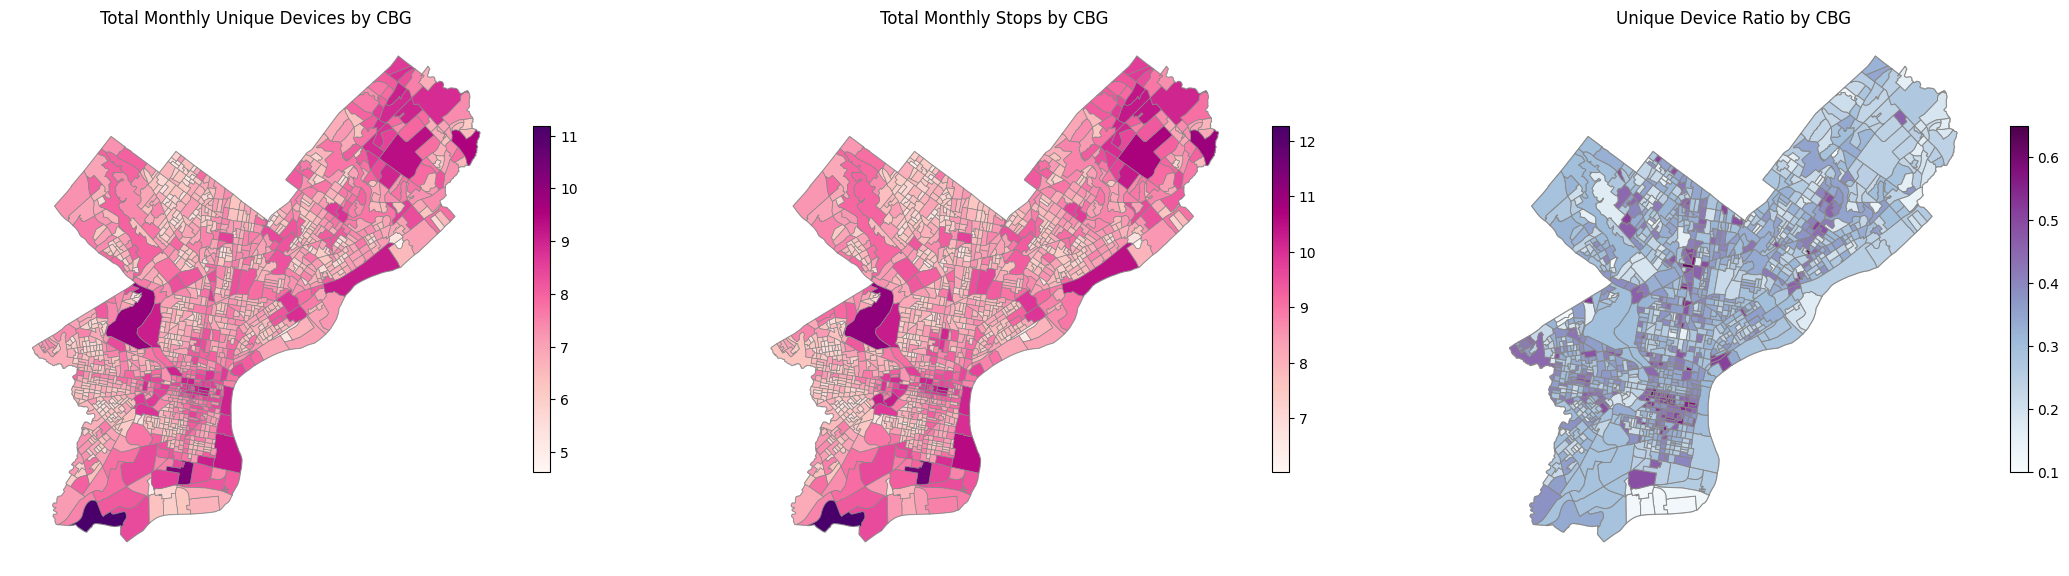

In [17]:
## plot missing cbgs
fig, axs = plt.subplots(1, 3, figsize = (27,9))

# Flatten axis array for easier indexing
axs = axs.flatten()

## plot total stop count, ax[0]
ax = axs[0]
philly_2023.plot(ax = ax, color='none', edgecolor='#888888', alpha = 0.7,figsize=(10, 8))  # base layer
result.plot(
    column=np.log1p(result['alloc_avg_d_cnt']),
    cmap='RdPu',       # or 'coolwarm', 'plasma', etc.
    legend=True,
    linewidth=0.5,
    edgecolor='#888888',
    ax=ax,
    legend_kwds={
        "shrink": 0.5,       # scale down the legend (0.5 = half size)
        "orientation": "vertical"        # keep vertical
    }
)

ax.set_title("Total Monthly Unique Devices by CBG")
ax.axis('off')

## plot unique devices count, ax[1]
ax = axs[1]
philly_2023.plot(ax = ax, color='none', edgecolor='#888888', alpha = 0.7,figsize=(10, 8))  # base layer
result.plot(
    column=np.log1p(result['alloc_avg_s_cnt']),
    cmap='RdPu',       # or 'coolwarm', 'plasma', etc.
    legend=True,
    linewidth=0.5,
    edgecolor='#888888',
    ax=ax,
    legend_kwds={
        "shrink": 0.5,       # scale down the legend (0.5 = half size)
        "orientation": "vertical"        # keep vertical
    }
)

ax.set_title("Total Monthly Stops by CBG")
ax.axis('off')

## plot unique device ratio, ax[2]
ax = axs[2]
philly_2023.plot(ax = ax, color='none', edgecolor='#888888', alpha = 0.7,figsize=(10, 8))  # base layer
result.plot(
    column='unique_device_ratio_aw',
    cmap='BuPu',       # or 'coolwarm', 'plasma', etc.
    legend=True,
    linewidth=0.7,
    edgecolor='#888888',
    ax=ax,
    legend_kwds={
        "shrink": 0.5,       # scale down the legend (0.5 = half size)
        "orientation": "vertical"        # keep vertical
    }
)

ax.set_title("Unique Device Ratio by CBG")
ax.axis('off')

plt.savefig('output/cbg_ft_avg_2023.png', dpi=500, bbox_inches='tight')
plt.show()

In [ ]:
## export merge ft avg data
#result.to_file('output/2023_cbg_ft_avg.geojson', driver='GeoJSON')

## 311 Reporting rate

### Import 311 and filter out illegal dumping cases

In [5]:
## import 311 data
## load 2024 data
pc311_24 = gpd.read_file('data/311/2024/public_cases_fc.shp')

## load 2023 data
pc311_23 = gpd.read_file('data/311/2023/public_cases_fc.shp')

## load 2022 data
pc311_22 = gpd.read_file('data/311/2022/public_cases_fc.shp')

## load 2021 data
pc311_21 = gpd.read_file('data/311/2021/public_cases_fc.shp')

In [6]:
datasets = [pc311_21, pc311_22, pc311_23, pc311_24]
dataset_names = ['pc311_21', 'pc311_22', 'pc311_23','pc311_24']
years = [2021, 2022, 2023, 2024]

# Process each dataset
for i, df in enumerate(datasets):
    # Remove rows where service_na is "Illegal Dumping"
    df_filtered = df[df['service_na'] != 'Illegal Dumping']
    
    # Add year column
    df_filtered['year'] = years[i]

    # change crs
    df_filtered = df_filtered.to_crs(epsg = 26918)
    
    # Update the dataset
    datasets[i] = df_filtered
    
    print(f"{dataset_names[i]}: Removed {len(df) - len(df_filtered)} 'Illegal Dumping' rows, added year {years[i]}")

# Reassign the cleaned datasets back to original variable names
pc311_21, pc311_22, pc311_23, pc311_24 = datasets

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


pc311_21: Removed 25375 'Illegal Dumping' rows, added year 2021


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


pc311_22: Removed 24037 'Illegal Dumping' rows, added year 2022


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


pc311_23: Removed 22590 'Illegal Dumping' rows, added year 2023


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


pc311_24: Removed 22173 'Illegal Dumping' rows, added year 2024


### Processing monthly ft data: align 2023 cbg

In [7]:
# Columns to keep from each dataframe
columns_to_keep = ['AREA', 'DATE_RANGE_START', 'DATE_RANGE_END', 'RAW_DEVICE_COUNTS', 'RAW_STOP_COUNTS', 'Y']

# List to store the merged GeoDataFrames
merged_gdf_list = []

# Process each dataframe in df_list
for i, df in enumerate(df_list):
    # Filter to keep only the specified columns
    df_filtered = df[columns_to_keep].copy()
    
    df_filtered['AREA'] = df_filtered['AREA'].astype(str)
    pa_2018['GEOID'] = pa_2018['GEOID'].astype(str)
    
    # Merge with pa_2018 using AREA from df and GEOID from pa_2018
    merged_df = df_filtered.merge(
        pa_2018, 
        left_on='AREA', 
        right_on='GEOID', 
        how='left'  # Use 'left' to keep all rows from df_filtered
    )
    
    # Convert to GeoDataFrame using the geometry from pa_2018
    merged_gdf = gpd.GeoDataFrame(
        merged_df, 
        geometry='geometry',  # assuming pa_2018 has a 'geometry' column
        crs=pa_2018.crs  # use the same CRS as pa_2018
    )
    
    # Add the merged GeoDataFrame to the list
    merged_gdf_list.append(merged_gdf)
    
    print(f"Processed GeoDataFrame {i+1}: {merged_gdf.shape[0]} rows, {merged_gdf.shape[1]} columns")
    print(f"CRS: {merged_gdf.crs}")
    print(f"Geometry column: {merged_gdf.geometry.name}")
    print("---")

Processed GeoDataFrame 1: 1336 rows, 19 columns
CRS: EPSG:4269
Geometry column: geometry
---
Processed GeoDataFrame 2: 1336 rows, 19 columns
CRS: EPSG:4269
Geometry column: geometry
---
Processed GeoDataFrame 3: 1336 rows, 19 columns
CRS: EPSG:4269
Geometry column: geometry
---
Processed GeoDataFrame 4: 1336 rows, 19 columns
CRS: EPSG:4269
Geometry column: geometry
---
Processed GeoDataFrame 5: 1336 rows, 19 columns
CRS: EPSG:4269
Geometry column: geometry
---
Processed GeoDataFrame 6: 1336 rows, 19 columns
CRS: EPSG:4269
Geometry column: geometry
---
Processed GeoDataFrame 7: 1336 rows, 19 columns
CRS: EPSG:4269
Geometry column: geometry
---
Processed GeoDataFrame 8: 1336 rows, 19 columns
CRS: EPSG:4269
Geometry column: geometry
---
Processed GeoDataFrame 9: 1336 rows, 19 columns
CRS: EPSG:4269
Geometry column: geometry
---
Processed GeoDataFrame 10: 1336 rows, 19 columns
CRS: EPSG:4269
Geometry column: geometry
---
Processed GeoDataFrame 11: 1336 rows, 19 columns
CRS: EPSG:4269
Geome

In [8]:
# Apply spatial interpolation to each merged GeoDataFrame
interpolated_results = []

# Define columns for interpolation
extensive_cols = ["RAW_DEVICE_COUNTS", "RAW_STOP_COUNTS"]  # counts to be split proportionally
intensive_col = "Y"  # ratio to be area-weighted averaged

for i, merged_gdf in enumerate(merged_gdf_list):
    print(f"Processing GeoDataFrame {i+1}...")
    
    # --- inputs ---
    A = merged_gdf.copy()       # source data with counts and ratios
    B = philly_2023.copy()      # target geography (finer CBGs)
    
    # --- extract month from DATE_RANGE_START ---
    A['DATE_RANGE_START'] = pd.to_datetime(A['DATE_RANGE_START'])
    month_value = A['DATE_RANGE_START'].dt.month.iloc[0]  # get month from first row (should be same for all)
    
    # --- project to meters (Philly) + fix geometries ---
    A = A.to_crs(26918)
    B = B.to_crs(26918)
    A["geometry"] = A.geometry.apply(make_valid)
    B["geometry"] = B.geometry.apply(make_valid)
    
    # --- keep needed columns + areas ---
    A = A[extensive_cols + [intensive_col, "geometry", "GEOID"]].copy()  # keep GEOID for reference
    B = B[["GEOID", "geometry"]].copy()
    
    A["aid"] = np.arange(len(A))
    A["area_A"] = A.area
    B["area_B"] = B.area
    B_area = B[["GEOID", "area_B"]]
    
    # --- intersections (handles splits, overlaps, reassignments) ---
    AB = gpd.overlay(
        A[["aid", "area_A"] + extensive_cols + [intensive_col, "geometry"]],
        B[["GEOID", "geometry"]],
        how="intersection",
        keep_geom_type=False
    )
    AB = AB[AB.geometry.notna() & ~AB.geometry.is_empty].copy()
    AB["area_int"] = AB.area
    AB = AB[AB["area_int"] > 0].copy()
    
    # share of A piece overlapped
    AB["share_A"] = AB["area_int"] / AB["area_A"]
    
    # --- EXTENSIVE: split totals from A into B by area share ---
    for col in extensive_cols:
        AB[f"alloc_{col}"] = AB[col] * AB["share_A"]
    
    ext_alloc = (AB.groupby("GEOID", as_index=False)
                   [[f"alloc_{c}" for c in extensive_cols]].sum())
    
    # --- INTENSIVE: area-weighted average into B ---
    AB = AB.merge(B_area, on="GEOID", how="left")
    AB["weighted_rate"] = AB[intensive_col] * AB["area_int"]
    rate = (AB.groupby("GEOID", as_index=False)
              .agg(weighted_sum=("weighted_rate", "sum"), 
                   area_B=("area_B", "first")))
    rate[f"{intensive_col}_aw"] = rate["weighted_sum"] / rate["area_B"]
    
    # --- attach results to B ---
    result = (B
              .merge(ext_alloc, on="GEOID", how="left")
              .merge(rate[["GEOID", f"{intensive_col}_aw"]], on="GEOID", how="left")
              .fillna({f"alloc_{c}": 0 for c in extensive_cols}))
    
    # --- add month information ---
    result['month'] = month_value
    
    # Store the result
    interpolated_results.append(result)
    
    print(f"  - Input shape: {A.shape}")
    print(f"  - Target shape: {B.shape}")
    print(f"  - Result shape: {result.shape}")
    print(f"  - Month: {month_value}")
    print(f"  - Columns in result: {result.columns.tolist()}")
    print("---")

print(f"Completed spatial interpolation for {len(interpolated_results)} GeoDataFrames")

# Access individual results:
# interpolated_results[0] = first interpolated result
# interpolated_results[1] = second interpolated result
# etc.

# Example: Check the first result
if interpolated_results:
    print("First interpolated result columns:")
    print(interpolated_results[0].columns.tolist())
    print("First few rows of first result:")
    print(interpolated_results[0].head())

Processing GeoDataFrame 1...
  - Input shape: (1336, 7)
  - Target shape: (1338, 3)
  - Result shape: (1338, 7)
  - Month: 1
  - Columns in result: ['GEOID', 'geometry', 'area_B', 'alloc_RAW_DEVICE_COUNTS', 'alloc_RAW_STOP_COUNTS', 'Y_aw', 'month']
---
Processing GeoDataFrame 2...
  - Input shape: (1336, 7)
  - Target shape: (1338, 3)
  - Result shape: (1338, 7)
  - Month: 2
  - Columns in result: ['GEOID', 'geometry', 'area_B', 'alloc_RAW_DEVICE_COUNTS', 'alloc_RAW_STOP_COUNTS', 'Y_aw', 'month']
---
Processing GeoDataFrame 3...
  - Input shape: (1336, 7)
  - Target shape: (1338, 3)
  - Result shape: (1338, 7)
  - Month: 8
  - Columns in result: ['GEOID', 'geometry', 'area_B', 'alloc_RAW_DEVICE_COUNTS', 'alloc_RAW_STOP_COUNTS', 'Y_aw', 'month']
---
Processing GeoDataFrame 4...
  - Input shape: (1336, 7)
  - Target shape: (1338, 3)
  - Result shape: (1338, 7)
  - Month: 4
  - Columns in result: ['GEOID', 'geometry', 'area_B', 'alloc_RAW_DEVICE_COUNTS', 'alloc_RAW_STOP_COUNTS', 'Y_aw', '

In [32]:
pc311_21.head()

,objectid,service_re,subject,status,status_not,service_na,service_co,agency_res,service_no,requested_,updated_da,expected_d,closed_dat,address,zipcode,media_url,lat,lon,geometry,year
0,2902196.0,13930089.0,Rubbish/Recyclable Material Collection,Closed,None,Rubbish/Recyclable Material Collection,SR-ST03,Streets Department,2 Business Days,2021-02-11,2022-03-12,2021-02-15,2021-03-02,1348 PENNINGTON RD,19151,None,39.971763,-75.265885,POINT (477294.773 4424657.028),2021
1,2902197.0,13930091.0,How do you contact the USPS?,Closed,Question Answered,Information Request,SR-IR01,Philly311 Contact Center,None,2021-02-11,2021-02-11,None,2021-02-11,None,None,None,NaN,NaN,None,2021
2,2902198.0,13930092.0,How can I get a rubbish / recycling pickup?-SE...,Closed,Question Answered,Information Request,SR-IR01,Streets Department,None,2021-02-11,2021-02-11,None,2021-02-11,None,None,None,NaN,NaN,None,2021
3,2902190.0,13930083.0,What day is trash/recycling collection in my n...,Closed,Question Answered,Information Request,SR-IR01,Streets Department,None,2021-02-11,2021-02-11,None,2021-02-11,None,None,None,NaN,NaN,None,2021
4,2902191.0,13930084.0,Rubbish/Recyclable Material Collection,Closed,None,Rubbish/Recyclable Material Collection,SR-ST03,Streets Department,2 Business Days,2021-02-11,2022-03-12,2021-02-15,2021-04-19,878 BUDD ST,19104,None,39.969631,-75.205172,POINT (482478.824 4424406.769),2021


### Calculating monthly 311 reporting rate 

In [33]:
## combinea all foot trafficdata
ft_all = gpd.GeoDataFrame(pd.concat(interpolated_results, ignore_index=True))
ft_all = ft_all[ft_all['Y_aw'] >= 2021]

# keep only year from Y_aw
ft_all['Y_aw'] = ft_all['Y_aw'].astype(str)
ft_all['Y_aw'] = ft_all['Y_aw'].str[:4].astype(int)

# create year_month column
ft_all['year_month'] = ft_all['Y_aw'] * 100 + ft_all['month']

In [ ]:
## combine all 311 data
all_311 = gpd.GeoDataFrame(pd.concat([pc311_21, pc311_22,pc311_23, pc311_24], ignore_index=True))

## extrac month and year from `requested_`` and create year_month column
all_311['requested_'] = pd.to_datetime(all_311['requested_'])
all_311['year_month'] = all_311['requested_'].dt.year * 100 + all_311['requested_'].dt.month

## keep only year_month and objectid
all_311 = all_311[['year_month', 'objectid', 'geometry']]

## filter out invalid geometry
initial_count = len(all_311)
all_311 = all_311[all_311['geometry'].notna()]
final_count = len(all_311)
removed_count = initial_count - final_count
print(f'Removed {removed_count} rows with invalid geometry')

Removed 1140880 rows with invalid geometry


In [24]:
## align crs
pa_2023 = pa_2023.to_crs(26918)

## spatial join all_311 with pa_2023 to assign GEOID
all_311 = all_311.sjoin(pa_2023, how='left', predicate='within')

## keep only year_month, objectid, GEOID
all_311 = all_311[['year_month', 'objectid', 'GEOID','geometry']]

In [71]:
## aggregate by year_month and GEOID
all_311_month = all_311.groupby(['year_month', 'GEOID']).size().reset_index(name='count')

## merge with ft_all and append na with 0
ft_all_month = ft_all.merge(all_311_month, on=['year_month', 'GEOID'], how='left')
ft_all_month['count'] = ft_all_month['count'].fillna(0)

## calculate reporting rate
ft_all_month['reporting_rate'] = ft_all_month['count'] / ft_all_month['alloc_RAW_STOP_COUNTS']

## keep only year_month, GEOID, reporting_rate and geometry
ft_all_month = ft_all_month[['year_month', 'GEOID', 'reporting_rate', 'geometry']]

## aggregate by GEOID: take monthly average keep it as gdf
ft_all_month_agg = ft_all_month.groupby('GEOID')['reporting_rate'].mean().reset_index()


<Axes: >

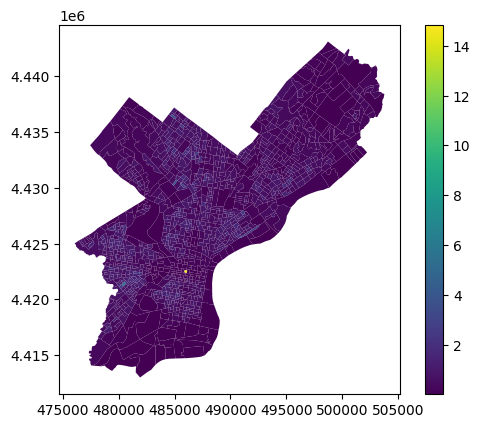

In [ ]:
## plotting to check
# add geometry to ft_all_month_agg
ft_all_month_agg['GEOID'] = ft_all_month_agg['GEOID'].astype(str)
pa_2023['GEOID'] = pa_2023['GEOID'].astype(str)

ft_all_month_gdf = ft_all_month_agg.merge(pa_2023[['GEOID', 'geometry']], on='GEOID', how='left')
ft_all_month_gdf = gpd.GeoDataFrame(ft_all_month_gdf, geometry='geometry')

ft_all_month_gdf['reporting_rate_100'] = ft_all_month_gdf['reporting_rate']*100
ft_all_month_gdf.plot(column='reporting_rate_100', cmap='viridis', legend=True)


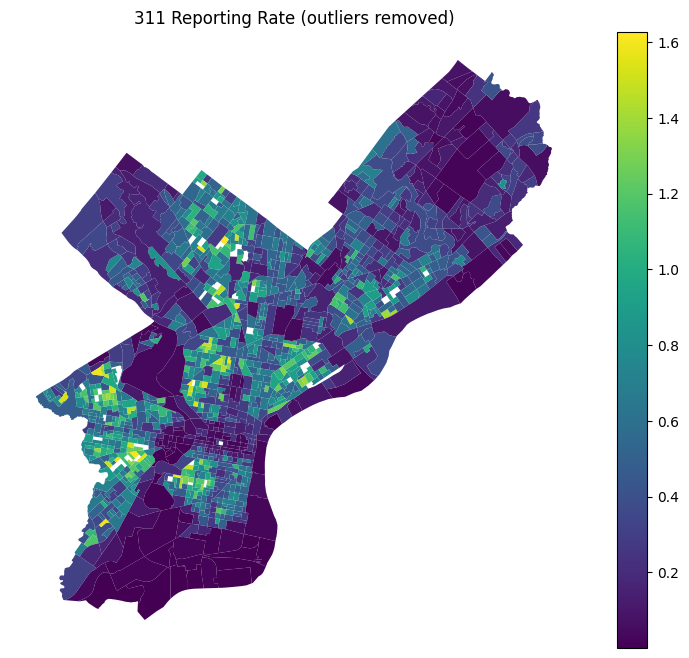

In [77]:
# Remove outliers using IQR method
Q1 = ft_all_month_gdf['reporting_rate_100'].quantile(0.25)
Q3 = ft_all_month_gdf['reporting_rate_100'].quantile(0.75)
IQR = Q3 - Q1

# Keep data within 1.5*IQR bounds
ft_cleaned = ft_all_month_gdf[
    (ft_all_month_gdf['reporting_rate_100'] >= Q1 - 1.5*IQR) & 
    (ft_all_month_gdf['reporting_rate_100'] <= Q3 + 1.5*IQR)
]

# Plot
ft_cleaned.plot(column='reporting_rate_100', cmap='viridis', legend=True, figsize=(10, 8))
plt.title('311 Reporting Rate (outliers removed)')
plt.axis('off')
plt.show()

In [76]:
ft_all_month_gdf['reporting_rate'].describe()

count    1338.000000
mean        0.006114
std         0.006129
min         0.000003
25%         0.002679
50%         0.005177
75%         0.008152
max         0.148534
Name: reporting_rate, dtype: float64

In [74]:
## export to csv
ft_all_month_agg.to_csv('output/ft_all_month_agg.csv', index=False)

## Zoom in Wissahickon park

In [9]:
## load PPR data
ppr =gpd.read_file('parks/PPR/PPR_Properties.geojson')
ppr = ppr.to_crs(26918)

In [10]:
## filter for Wissahickon park
wissahickon_rows = ppr[ppr['PUBLIC_NAME'].str.contains('Wissahickon', case=False, na=False)]

# Combine all Wissahickon geometries into one
wissahickon_union = wissahickon_rows.unary_union

# Get bounding box and expand by buffer value (square)
buffer_val = 300  # meters
minx, miny, maxx, maxy = wissahickon_union.bounds
wissahickon_square = geom.box(minx - buffer_val, miny - buffer_val,
                              maxx + buffer_val, maxy + buffer_val)

# Wrap into GeoDataFrame for plotting/export
wissahickon_square_gdf = gpd.GeoDataFrame(geometry=[wissahickon_square], crs=wissahickon_rows.crs)

In [11]:
## filter foot traffic data within the park
df_avg_geo_w = df_avg_geo.sjoin(wissahickon_square_gdf, predicate='intersects')

<Axes: >

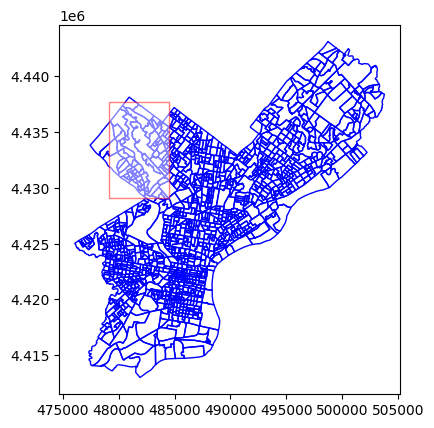

In [25]:
fig,ax = plt.subplots()

philly_2023.plot(ax=ax, edgecolor = "blue", color = "none")
wissahickon_square_gdf.plot(ax=ax, edgecolor = "red", color = "white", alpha = 0.5)

(477040.15357576404, 485970.02004545694, 4427845.2306230655, 4438581.015211997)

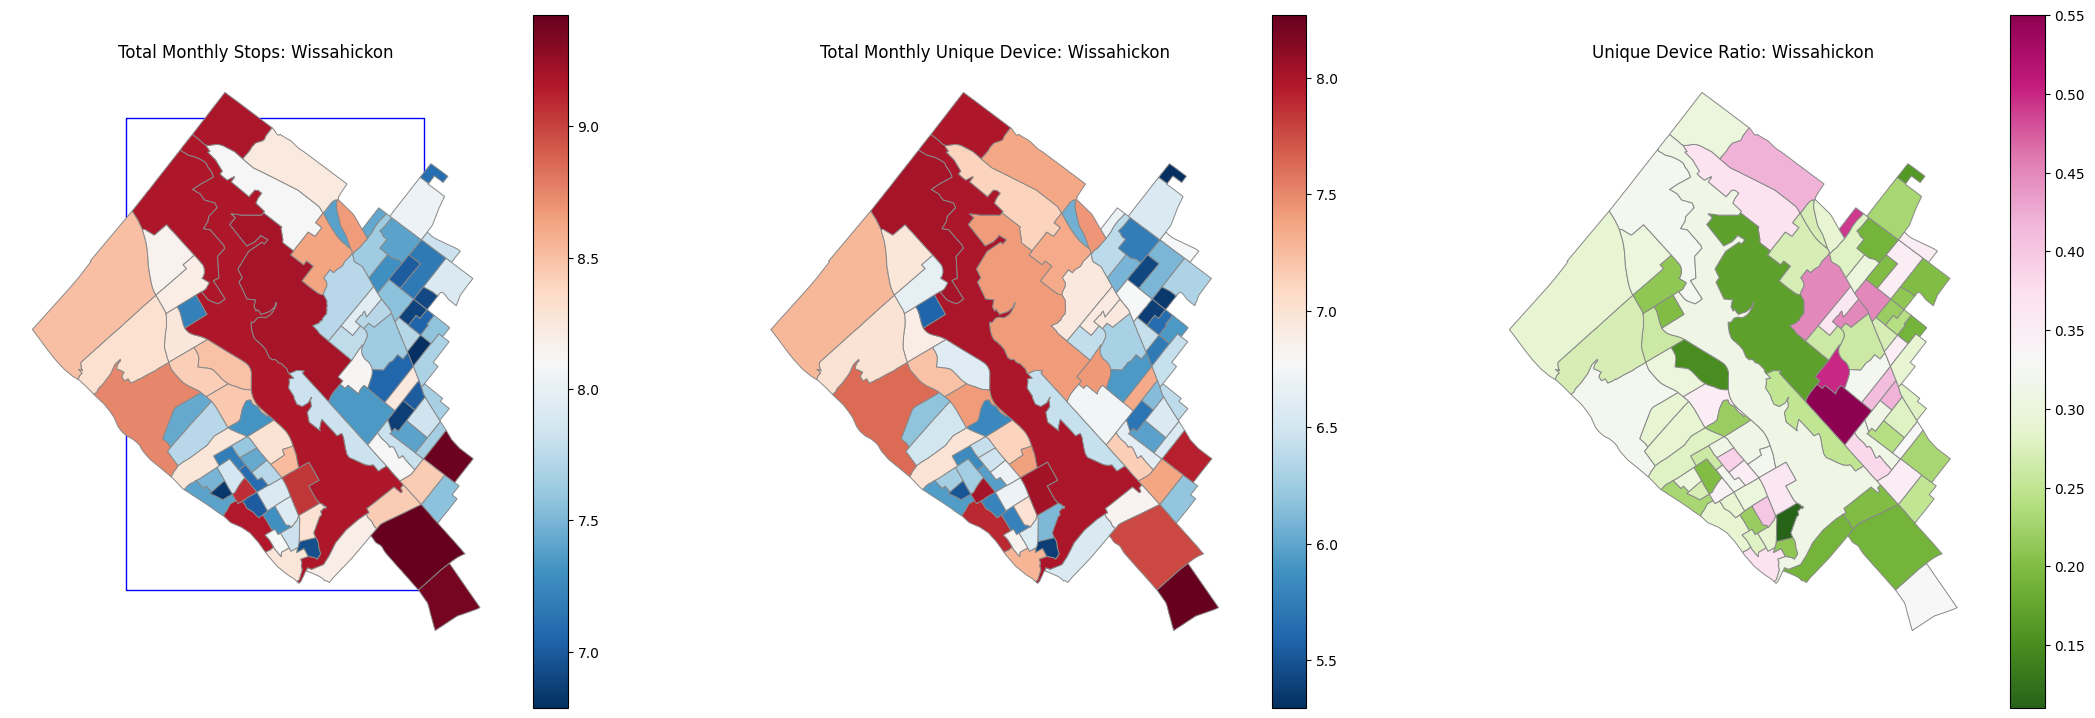

In [31]:
## set up subplot
fig, axs = plt.subplots(1, 3, figsize = (27,9))

# Flatten axis array for easier indexing
axs = axs.flatten()

## plot total stop count, ax[0]
ax = axs[0]
wissahickon_square_gdf.plot(ax=ax, edgecolor = "blue", color = "none")
df_avg_geo_w.plot(
    column=np.log1p(df_avg_geo_w['avg_s_cnt']),
    cmap='RdBu_r',       # or 'coolwarm', 'plasma', etc.
    legend=True,
    linewidth=0.7,
    edgecolor='#888888',
    ax=ax
)

ax.set_title("Total Monthly Stops: Wissahickon")
ax.axis('off')

## plot unique devices count, ax[1]
ax = axs[1]
df_avg_geo_w.plot(
    column=np.log1p(df_avg_geo_w['avg_d_cnt']),
    cmap='RdBu_r',       # or 'coolwarm', 'plasma', etc.
    legend=True,
    linewidth=0.7,
    edgecolor='#888888',
    ax=ax
)

ax.set_title("Total Monthly Unique Device: Wissahickon")
ax.axis('off')

## plot unique device ratio, ax[2]
ax = axs[2]
df_avg_geo_w.plot(
    column='unique_device_ratio',
    cmap='PiYG_r',       # or 'coolwarm', 'plasma', etc.
    legend=True,
    linewidth=0.7,
    edgecolor='#888888',
    ax=ax
)

ax.set_title("Unique Device Ratio: Wissahickon")
ax.axis('off')

##### Plotting with zoning data

In [13]:
## load zoning data
land_use_current = gpd.read_file('output/land_use.geojson')

## Customize color map for land use categories
use_lst = ['Res Low Den', 'Res Med Den', 'Res High Den', 'Commercial', 'Civic', 'Industry', 'Transportation', 'Green ROW', 'Water', 'Vacant', 'Other']
colors = ['#543f32', '#db4d6d', '#69821b', '#e6b422', '#5654a2','#0095d9', '#a73836', '#a8bf93','#164a84', '#b3ada0','#d3cfd9']

use_color = dict(zip(colors,use_lst))

## reset order in land_use_currect
land_use_current['type'] = pd.Categorical(land_use_current['type'], categories=use_lst, ordered=True)

land_use_current = land_use_current.to_crs(epsg=26918)

(477040.15357576404, 485970.02004545694, 4427845.2306230655, 4438581.015211997)

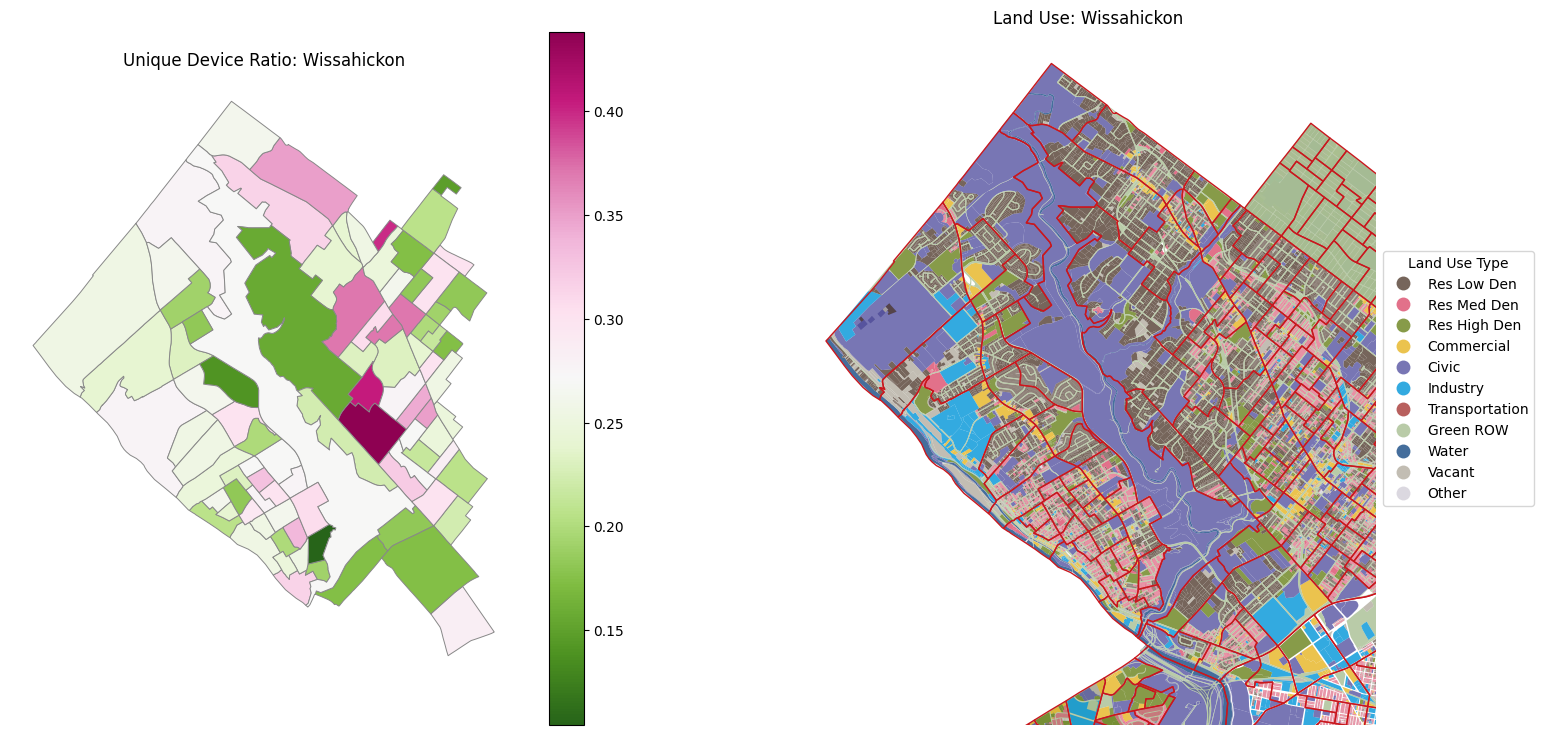

In [28]:
## set up subplot
fig, axs = plt.subplots(1, 2, figsize = (18,9))

# Flatten axis array for easier indexing
axs = axs.flatten()

# Match limits from left subplot
df_avg_geo_w.plot(
    column=np.log1p(df_avg_geo_w['unique_device_ratio']),
    cmap='PiYG_r',
    legend=True,
    linewidth=0.7,
    edgecolor='#888888',
    ax=axs[0]
)
axs[0].set_title("Unique Device Ratio: Wissahickon")
axs[0].axis('off')

# Get limits after plotting
xlim = axs[0].get_xlim()
ylim = axs[0].get_ylim()

# --- Second plot ---
land_use_current['type'] = land_use_current['type'].astype('category')
cmap = ListedColormap(use_color)

land_use_current[land_use_current['year'] == 2023].plot(
    ax=axs[1],
    column='type',
    cmap=cmap,
    alpha=0.8,
    legend=True,
    legend_kwds={
        'loc': 'center left',
        'bbox_to_anchor': (1, 0.5),
        'title': 'Land Use Type'
    }
)
philly_2023.plot(ax=axs[1], edgecolor = "#c9171e", color = "none")

# Apply limits from axs[0]
axs[1].set_xlim(xlim)
axs[1].set_ylim(ylim)

axs[1].set_title("Land Use: Wissahickon")
axs[1].axis('off')
